<a href="https://colab.research.google.com/github/gaga0321/scRNA-aging-analysis/blob/main/scRNA_aging_analysis_liver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


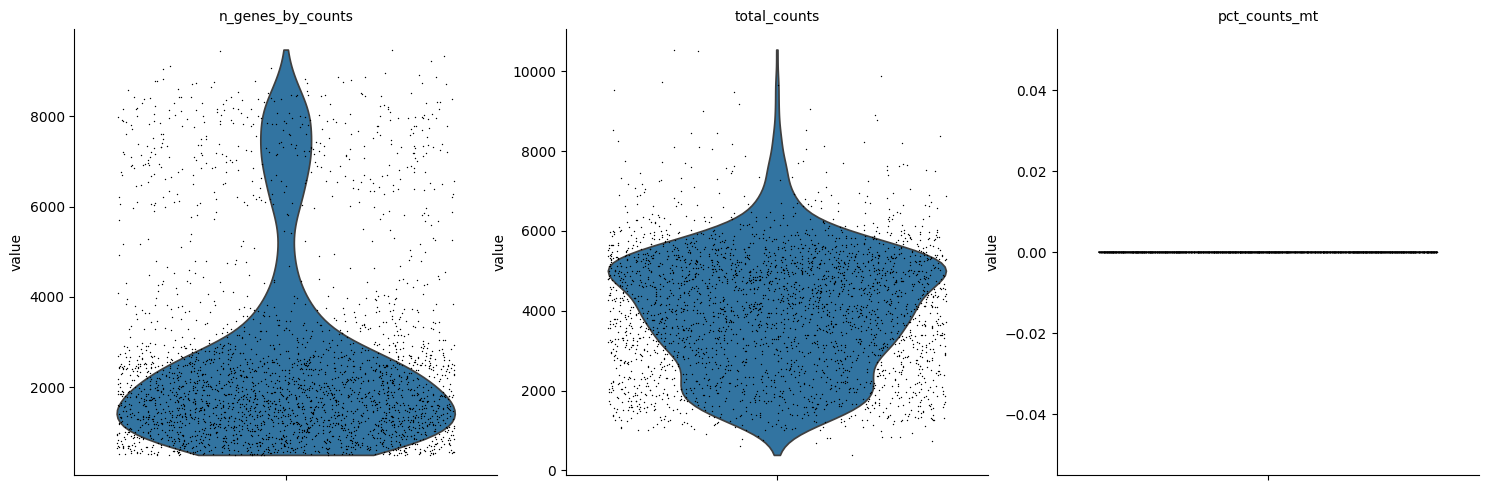

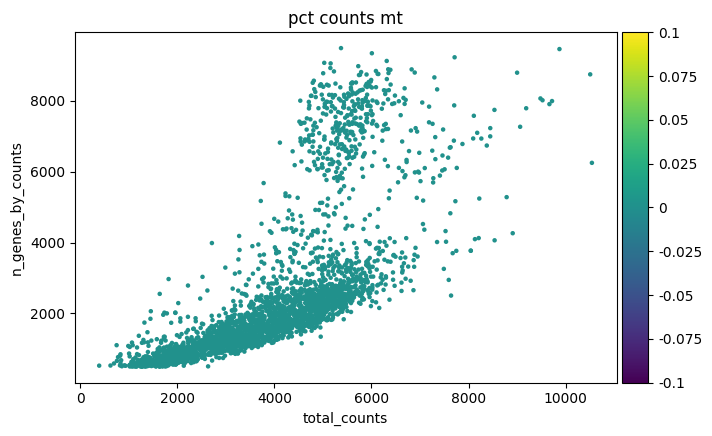

['FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']


In [ ]:
!pip install scanpy
import scanpy as sc
adata_aging = sc.read_h5ad("tabula-muris-senis-facs-processed-official-annotations-Liver.h5ad")
adata_aging.var['mt'] = adata_aging.var_names.str.lower().str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata_aging, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pl.violin(
    adata_aging,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    size=1
)
sc.pl.scatter(adata_aging, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt')
print(list(adata_aging.obs.columns))

In [ ]:
import scanpy as sc
adata_aging.var['mt'] = adata_aging.var_names.str.lower().str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata_aging, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
print(f"Cells before QC: {adata_aging.n_obs}")
adata_aging = adata_aging[
    (adata_aging.obs.n_genes_by_counts < 4500) &   # Kills the Doublets
    (adata_aging.obs.n_genes_by_counts > 500),     # Kills the Empty Debris
    :
].copy()
print(f"Cells after QC: {adata_aging.n_obs}")

Cells before QC: 2859
Cells after QC: 2420


Ages in this cohort: ['18m', '24m', '3m']

Top 5 cell types found in this tissue:
cell_ontology_class
hepatocyte                              813
endothelial cell of hepatic sinusoid    593
Kupffer cell                            220
B cell                                  208
myeloid leukocyte                       191
Name: count, dtype: int64


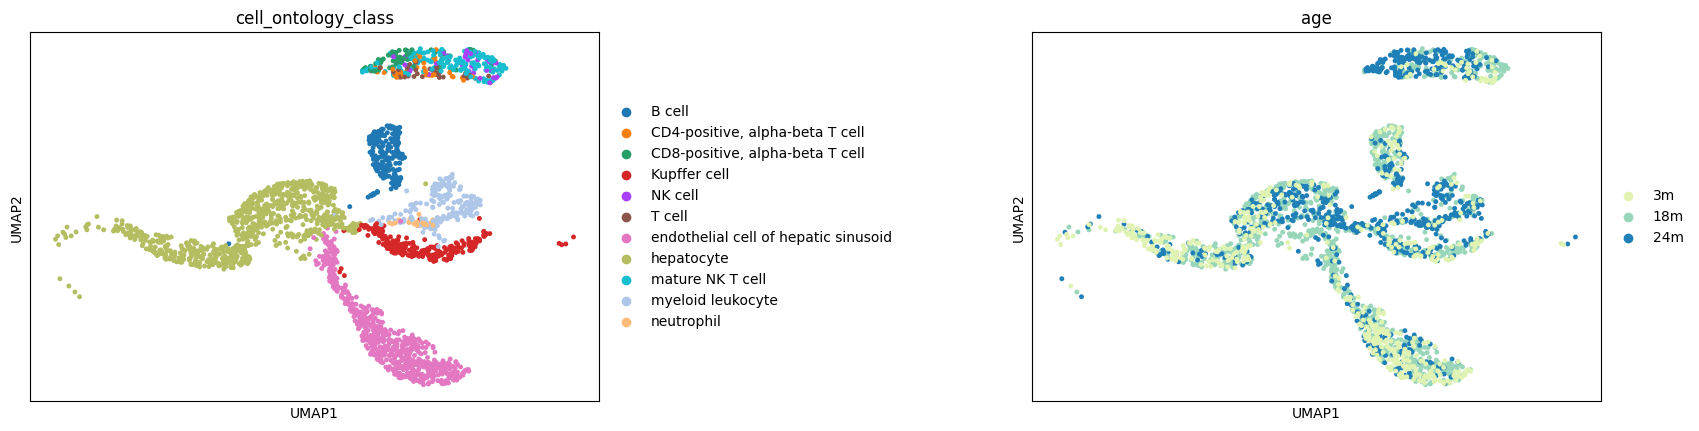

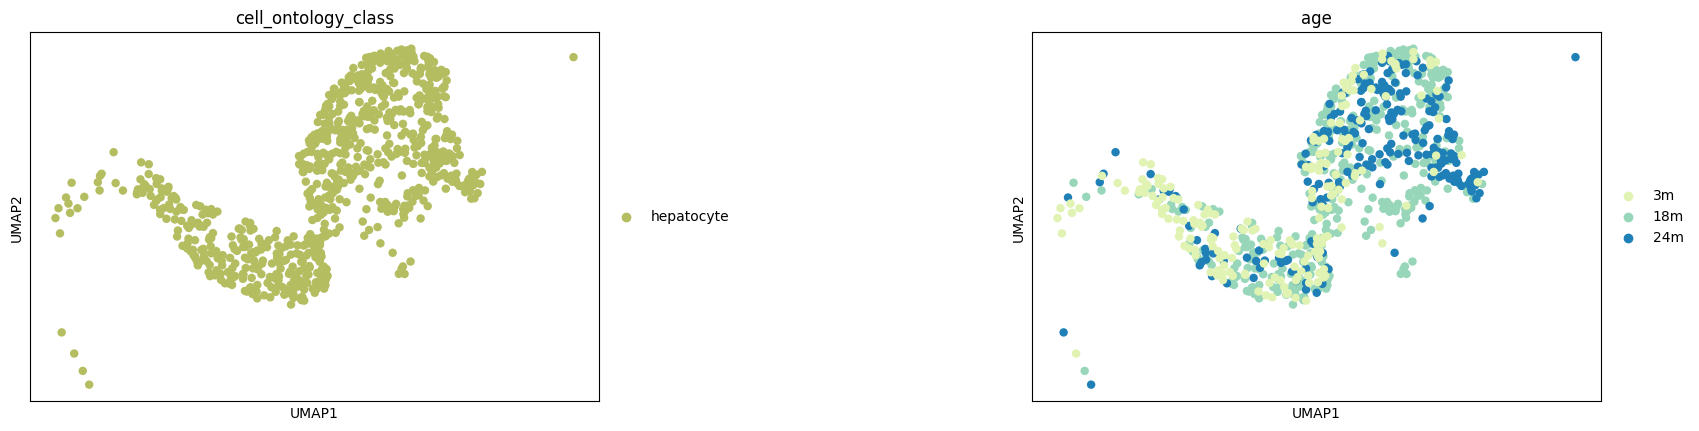

In [ ]:
print("Ages in this cohort:", adata_aging.obs['age'].unique().tolist())
print("\nTop 5 cell types found in this tissue:")
print(adata_aging.obs['cell_ontology_class'].value_counts().head(5))
sc.pl.umap(adata_aging, color=['cell_ontology_class', 'age'], wspace=0.6)
hepatocyte_cells = adata_aging[adata_aging.obs['cell_ontology_class'] == 'hepatocyte'].copy()
sc.pl.umap(hepatocyte_cells, color=['cell_ontology_class', 'age'], wspace=0.6)

Top Upregulated Hepatocyte Drivers (Ranked by Fold Change):
       18m_n     18m_l         18m_p
0       Ptms  2.500560  8.906842e-18
1     Anp32a  2.192909  9.573131e-08
2       Saa2  1.737434  1.724313e-09
3        Aes  1.648651  3.706159e-12
4       Saa1  1.589258  8.771181e-08
5       Cfl1  1.494109  8.053931e-07
6      Cald1  1.283237  5.740855e-06
7     Cyb5r3  1.207118  8.285031e-08
8       Gpx3  1.201345  1.023903e-07
9       Ass1  1.173067  4.110919e-07
10      Oaz1  1.058797  2.576031e-06
11      Actb  1.023734  5.950362e-14
12  Hsp90ab1  1.011173  2.936069e-08
13      Pfn1  0.858667  6.546842e-06
14       Ubb  0.689479  3.904838e-06
15    H2-Q10  0.654689  2.660146e-09
16      Ambp  0.636030  2.941705e-07
17      Ftl1  0.605519  5.492511e-12


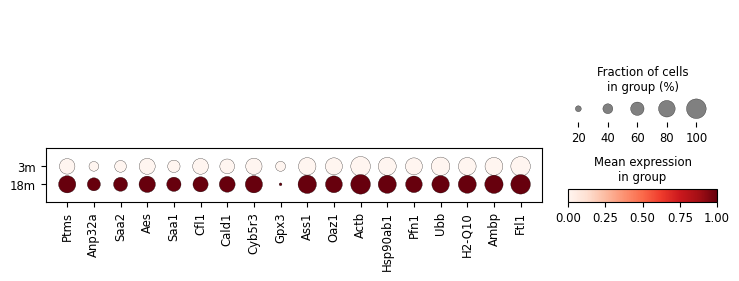

Top Downregulated Hepatocyte Targets (Ranked by Fold Change):
       18m_n     18m_l         18m_p
0       Plp1 -7.141458  3.185601e-16
1    Tmem119 -6.856913  4.010363e-06
2      Lars2 -3.876543  5.811510e-57
3     Ehhadh -3.396902  7.071016e-09
4    Aldh6a1 -3.319227  1.218872e-10
5       Mug2 -3.225102  1.431143e-06
6       Ttpa -3.076790  1.910243e-16
7    Slco1a1 -3.066500  1.426629e-06
8    Akr1c14 -2.971340  8.855521e-09
9       Crot -2.960388  4.436159e-29
10    Ugt2b1 -2.925398  6.038588e-06
11       Gsn -2.847484  2.100858e-39
12     Abcd3 -2.817219  4.139550e-10
13    Selplg -2.809873  5.459855e-08
14  Slc22a30 -2.739330  3.930529e-06
15    Acad11 -2.687726  1.463004e-08
16      Ddb1 -2.678624  3.606752e-06
17      Mug1 -2.657970  2.469189e-15
18      Egr1 -2.629096  3.450148e-10
19      Cps1 -2.602497  3.319180e-13


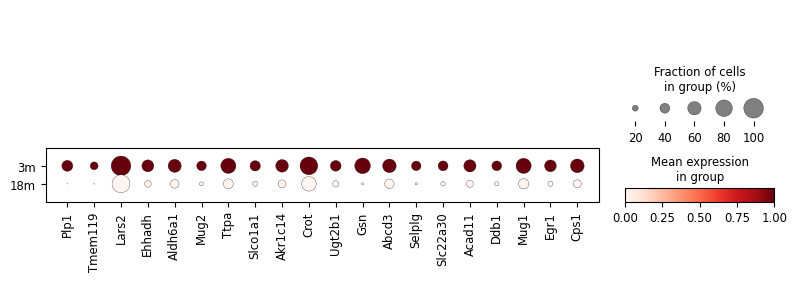

In [ ]:
import pandas as pd
sc.tl.rank_genes_groups(
    hepatocyte_cells,
    groupby='age',
    groups=['18m'],
    reference='3m',
    method='wilcoxon',
    use_raw=False
)
result = hepatocyte_cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0.5) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 1e-5].sort_values(by='18m_l', ascending=False).reset_index(drop=True)
print("Top Upregulated Hepatocyte Drivers (Ranked by Fold Change):")
print(final_up_df[['18m_n', '18m_l', '18m_p']].head(20))
top_genes = final_up_df['18m_n'].head(20).tolist()
subset = hepatocyte_cells[hepatocyte_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

downregulated_genes = dataframe[
    (dataframe['18m_l'] < -0.5) &
    (dataframe['18m_l'] > -15) &
    (dataframe['18m_l'] != float('-inf'))
]
final_down_df = downregulated_genes[downregulated_genes['18m_p'] < 1e-5].sort_values(by='18m_l', ascending=True).reset_index(drop=True)
print("Top Downregulated Hepatocyte Targets (Ranked by Fold Change):")
print(final_down_df[['18m_n', '18m_l', '18m_p']].head(20))
top_down_genes = final_down_df['18m_n'].head(20).tolist()
subset = hepatocyte_cells[hepatocyte_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset,
    var_names=top_down_genes,
    groupby='age',
    standard_scale='var',
    use_raw=False
)

Top 10 Upregulated Pathways in Aged Hepatocytes:
                                                Term  Adjusted P-value Overlap
0  Host-Mediated Suppression of Symbiont Invasion...          0.001959    3/19
1        Response to Type II Interferon (GO:0034341)          0.032878    3/60
2  Regulation of Interleukin-1 Production (GO:003...          0.047747    2/16
3          Response to Interferon-Alpha (GO:0035455)          0.049611    2/19
4  Positive Regulation of Transforming Growth Fac...          0.049611    2/24
5  Positive Regulation of Cellular Response to Tr...          0.049611    2/24
6   Hydrogen Peroxide Metabolic Process (GO:0042743)          0.049611    2/28
7           Response to Interferon-Beta (GO:0035456)          0.049611    2/29
8  Positive Regulation of Nitric Oxide Biosynthet...          0.049611    2/30
9                  Response to Cytokine (GO:0034097)          0.049611   3/123


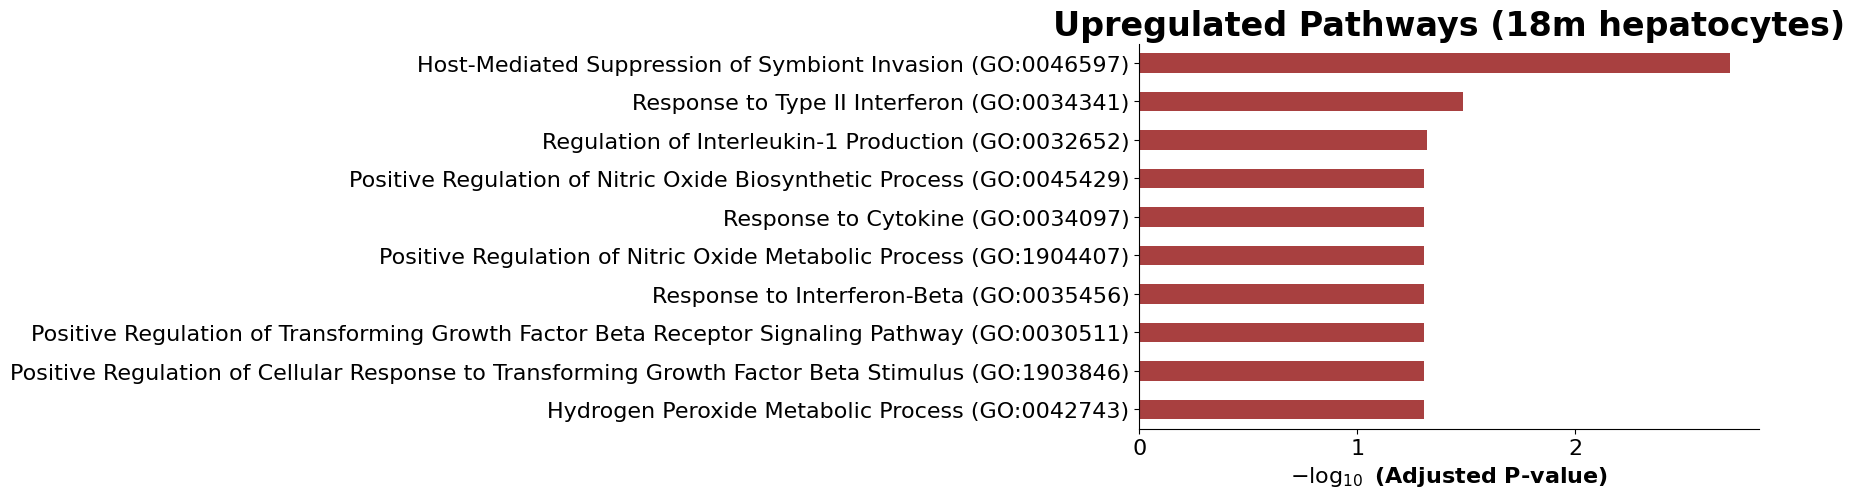

In [12]:
!pip install gseapy
import gseapy as gp
import matplotlib.pyplot as plt

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0.25) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 1e-3].sort_values(by='18m_l', ascending=False).reset_index(drop=True)

clean_up_genes = final_up_df['18m_n'].head(300).tolist()
enr_up = gp.enrichr(
    gene_list=clean_up_genes,
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
results_up_df = enr_up.results
print("Top 10 Upregulated Pathways in Aged Hepatocytes:")
print(results_up_df[['Term', 'Adjusted P-value', 'Overlap']].head(10))
gp.barplot(
    enr_up.results,
    column="Adjusted P-value",
    title='Upregulated Pathways (18m hepatocytes)',
    top_term=10,
    figsize=(8, 5),
    color='darkred'
)
plt.show()